# Day 2 - Customer Segmentation

## Objective

Segment Uber Eats customers based on their purchasing behavior using
K-Means and DBSCAN clustering algorithms.

## Business Goal

Identify distinct customer groups based on order frequency,
spending behavior, and purchasing patterns.

The resulting customer segments will be interpreted as business
personas and used to recommend targeted customer strategies.# Day 2 - Customer & Restaurant Segmentation

## Objective

Segment Uber Eats customers and restaurants using unsupervised
machine learning techniques.

## Customer Segmentation

Customer behavior will be analyzed using:
- Total orders
- Average order value
- Total spending
- Ordering frequency
- Average rating given
- Weekend orders
- Late-night orders

The customer segments will be identified using K-Means and DBSCAN,
followed by PCA visualization and business interpretation.

In [35]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, DBSCAN
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA

In [36]:
customers = pd.read_csv("../data/raw/customers.csv")
orders = pd.read_csv("../data/raw/orders.csv")
reviews = pd.read_csv("../data/raw/reviews.csv")

In [ ]:
print("Customers:", customers.shape)
print("Orders:", orders.shape)
print("Reviews:", reviews.shape)

Customers: (2000, 6)
Orders: (10000, 9)
Reviews: (7000, 5)


In [5]:
orders["order_timestamp"].head()

0    2025-01-10 17:00:00
1    2025-02-15 05:00:00
2    2025-03-16 02:00:00
3    2025-02-17 01:00:00
4    2025-01-27 20:00:00
Name: order_timestamp, dtype: str

In [39]:
orders.head()

,order_id,customer_id,restaurant_id,order_timestamp,order_amount,number_of_items,weather,traffic_condition,order_status
0,O00001,C00489,R0048,2025-01-10 17:00:00,1552.79,2,Rainy,Medium,Completed
1,O00002,C01953,R0077,2025-02-15 05:00:00,1562.78,2,Clear,High,Completed
2,O00003,C00397,R0024,2025-03-16 02:00:00,1653.23,5,Clear,High,Completed
3,O00004,C00896,R0054,2025-02-17 01:00:00,1698.19,1,Rainy,Medium,Completed
4,O00005,C00355,R0095,2025-01-27 20:00:00,898.83,6,Cloudy,Medium,Completed


In [44]:
orders["order_timestamp"] = pd.to_datetime(
    orders["order_timestamp"]
)

In [45]:
orders.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 9 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   order_id           10000 non-null  str           
 1   customer_id        10000 non-null  str           
 2   restaurant_id      10000 non-null  str           
 3   order_timestamp    10000 non-null  datetime64[us]
 4   order_amount       10000 non-null  float64       
 5   number_of_items    10000 non-null  int64         
 6   weather            10000 non-null  str           
 7   traffic_condition  10000 non-null  str           
 8   order_status       10000 non-null  str           
dtypes: datetime64[us](1), float64(1), int64(1), str(6)
memory usage: 703.3 KB


In [46]:
orders["order_timestamp"].dtype

dtype('<M8[us]')

In [47]:
orders["order_hour"] = orders["order_timestamp"].dt.hour

In [48]:
orders["day_of_week"] = orders["order_timestamp"].dt.dayofweek

In [49]:
orders["is_weekend"] = (
    orders["day_of_week"] >= 5
).astype(int)

In [50]:
orders["is_late_night"] = (
    (orders["order_hour"] >= 22) |
    (orders["order_hour"] < 4)
).astype(int)

In [51]:
customer_features = orders.groupby("customer_id").agg(
    total_orders=("order_id", "count"),
    total_spending=("order_amount", "sum"),
    average_order_value=("order_amount", "mean"),
    average_items=("number_of_items", "mean"),
    weekend_orders=("is_weekend", "sum"),
    late_night_orders=("is_late_night", "sum")
).reset_index()

In [52]:
customer_dates = orders.groupby("customer_id").agg(
    first_order=("order_timestamp", "min"),
    last_order=("order_timestamp", "max")
).reset_index()

In [53]:
customer_dates["active_days"] = (
    customer_dates["last_order"] -
    customer_dates["first_order"]
).dt.days + 1

In [54]:
customer_features = customer_features.merge(
    customer_dates[
        ["customer_id", "active_days"]
    ],
    on="customer_id",
    how="left"
)

In [55]:
customer_features["ordering_frequency"] = (
    customer_features["total_orders"] /
    customer_features["active_days"]
)

In [56]:
rating_features = reviews.groupby("customer_id").agg(
    average_rating_given=("rating", "mean")
).reset_index()

In [57]:
customer_features = customer_features.merge(
    rating_features,
    on="customer_id",
    how="left"
)

In [58]:
customer_features = customers[
    ["customer_id"]
].merge(
    customer_features,
    on="customer_id",
    how="left"
)

In [64]:
customer_features.isnull().sum()

customer_id              0
total_orders             0
total_spending           0
average_order_value      0
average_items            0
weekend_orders           0
late_night_orders        0
active_days              0
ordering_frequency       0
average_rating_given    48
dtype: int64

In [60]:
behavior_columns = [
    "total_orders",
    "total_spending",
    "average_order_value",
    "average_items",
    "weekend_orders",
    "late_night_orders",
    "active_days",
    "ordering_frequency"
]

customer_features[behavior_columns] = (
    customer_features[behavior_columns].fillna(0)
)

In [65]:
rating_mean = customer_features["average_rating_given"].mean()

customer_features["average_rating_given"] = (
    customer_features["average_rating_given"]
    .fillna(rating_mean)
)

In [66]:
customer_features.isnull().sum()

customer_id             0
total_orders            0
total_spending          0
average_order_value     0
average_items           0
weekend_orders          0
late_night_orders       0
active_days             0
ordering_frequency      0
average_rating_given    0
dtype: int64

In [67]:
model_features = [
    "total_orders",
    "total_spending",
    "average_order_value",
    "average_items",
    "weekend_orders",
    "late_night_orders",
    "ordering_frequency",
    "average_rating_given"
]

In [68]:
customer_features[model_features].describe()

,total_orders,total_spending,average_order_value,average_items,weekend_orders,late_night_orders,ordering_frequency,average_rating_given
count,2000.000000,2000.00000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000
mean,5.000000,5247.74714,1042.609207,3.506127,1.453500,1.263500,0.137014,3.584808
std,2.200323,2616.32776,279.009056,0.893094,1.220485,1.133009,0.190638,0.782667
min,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
25%,3.000000,3328.72250,869.560917,3.000000,1.000000,0.000000,0.070423,3.000000
50%,5.000000,5037.35000,1046.904464,3.500000,1.000000,1.000000,0.092593,3.600000
75%,6.000000,6861.60250,1214.446071,4.000000,2.000000,2.000000,0.123288,4.000000
max,13.000000,16171.87000,1984.195000,6.000000,8.000000,7.000000,2.000000,5.000000


In [69]:
scaler = StandardScaler()

X = customer_features[model_features]

X_scaled = scaler.fit_transform(X)

X_scaled = pd.DataFrame(
    X_scaled,
    columns=model_features,
    index=customer_features.index
)

In [70]:
X_scaled.describe()

,total_orders,total_spending,average_order_value,average_items,weekend_orders,late_night_orders,ordering_frequency,average_rating_given
count,2.000000e+03,2.000000e+03,2.000000e+03,2.000000e+03,2.000000e+03,2.000000e+03,2.000000e+03,2.000000e+03
mean,-3.552714e-18,-1.580958e-16,-6.572520e-16,1.740830e-16,1.953993e-17,-1.776357e-17,6.483702e-17,7.815970e-17
std,1.000250e+00,1.000250e+00,1.000250e+00,1.000250e+00,1.000250e+00,1.000250e+00,1.000250e+00,1.000250e+00
min,-2.272962e+00,-2.006270e+00,-3.737764e+00,-3.926803e+00,-1.191218e+00,-1.115451e+00,-7.188917e-01,-3.303391e+00
25%,-9.091848e-01,-7.336637e-01,-6.203798e-01,-5.668538e-01,-3.716667e-01,-1.115451e+00,-3.493950e-01,-7.473863e-01
50%,0.000000e+00,-8.043708e-02,1.539854e-02,-6.862246e-03,-3.716667e-01,-2.326247e-01,-2.330719e-01,1.941521e-02
75%,4.545924e-01,6.169942e-01,6.160368e-01,5.531293e-01,4.478850e-01,6.502015e-01,-7.201935e-02,5.306162e-01
max,3.636739e+00,4.176409e+00,3.375594e+00,2.793096e+00,5.365195e+00,5.064332e+00,9.774815e+00,1.808619e+00


In [71]:
inertia = []
silhouette_scores = []

k_values = range(2, 9)

for k in k_values:
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )
    
    labels = kmeans.fit_predict(X_scaled)
    
    inertia.append(kmeans.inertia_)
    silhouette_scores.append(
        silhouette_score(X_scaled, labels)
    )

In [72]:
results = pd.DataFrame({
    "k": list(k_values),
    "inertia": inertia,
    "silhouette_score": silhouette_scores
})

results

,k,inertia,silhouette_score
0,2,12568.476739,0.193305
1,3,10671.007513,0.215310
2,4,9584.506844,0.158901
3,5,8907.358574,0.149184
4,6,8356.660055,0.134996
5,7,7858.115152,0.140024
6,8,7398.456039,0.145544


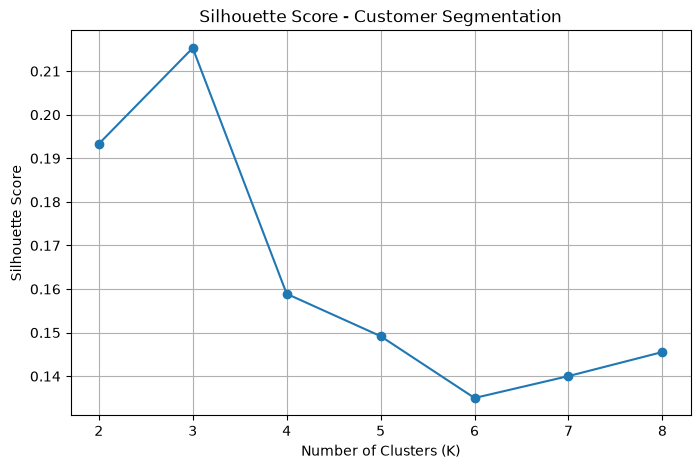

In [76]:
plt.figure(figsize=(8, 5))

plt.plot(
    results["k"],
    results["silhouette_score"],
    marker="o"
)

plt.xlabel("Number of Clusters (K)")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Score - Customer Segmentation")
plt.xticks(results["k"])
plt.grid(True)

plt.show()

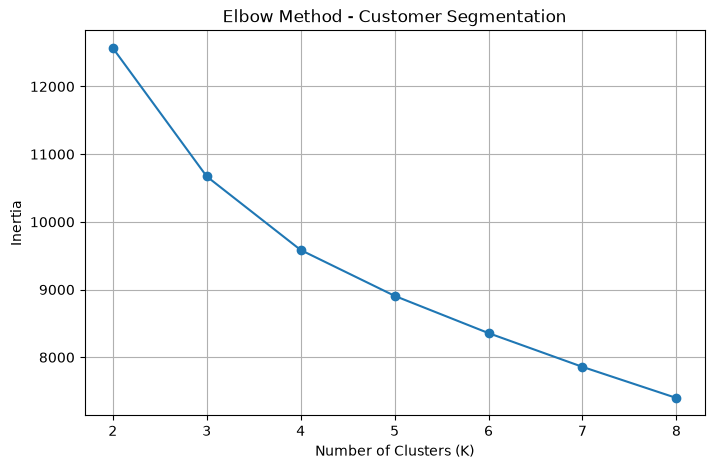

In [77]:
plt.figure(figsize=(8, 5))

plt.plot(
    results["k"],
    results["inertia"],
    marker="o"
)

plt.xlabel("Number of Clusters (K)")
plt.ylabel("Inertia")
plt.title("Elbow Method - Customer Segmentation")
plt.xticks(results["k"])
plt.grid(True)

plt.savefig("../outputs/figures/customer_elbow.png",
            bbox_inches="tight")

plt.show()

In [78]:
final_kmeans = KMeans(
    n_clusters=3,
    random_state=42,
    n_init=10
)

customer_features["customer_cluster"] = (
    final_kmeans.fit_predict(X_scaled)
)

In [79]:
customer_features["customer_cluster"].value_counts().sort_index()

customer_cluster
0      75
1     751
2    1174
Name: count, dtype: int64

In [80]:
cluster_profile = customer_features.groupby(
    "customer_cluster"
)[model_features].mean()

cluster_profile

,total_orders,total_spending,average_order_value,average_items,weekend_orders,late_night_orders,ordering_frequency,average_rating_given
customer_cluster,,,,,,,,
0,1.240000,1307.197333,1039.066796,3.743556,0.360000,0.280000,1.028000,3.326962
1,7.109188,7746.407044,1100.226524,3.513782,2.299601,2.042610,0.110999,3.586070
2,3.890971,3901.109702,1005.978096,3.486062,0.982112,0.827939,0.096735,3.600473


### Customer Segment Interpretation

- Cluster 0 represents occasional/low-value customers with relatively low
  order frequency and spending.

- Cluster 1 represents frequent and high-value customers with the highest
  order volume and total spending.

- Cluster 2 represents moderate-value customers who fall between the
  occasional and frequent customer groups.

These segments can help Uber Eats design differentiated retention,
engagement, and promotional strategies.

In [81]:
pca = PCA(n_components=2)

X_pca = pca.fit_transform(X_scaled)

pca_df = pd.DataFrame(
    X_pca,
    columns=["PC1", "PC2"]
)

pca_df["customer_cluster"] = (
    customer_features["customer_cluster"].values
)

pca_df.head()

,PC1,PC2,customer_cluster
0,-0.283706,-0.415231,2
1,-1.210799,-0.196412,2
2,-1.440662,-0.609821,2
3,-0.484420,1.336341,2
4,-0.615248,-0.717844,2


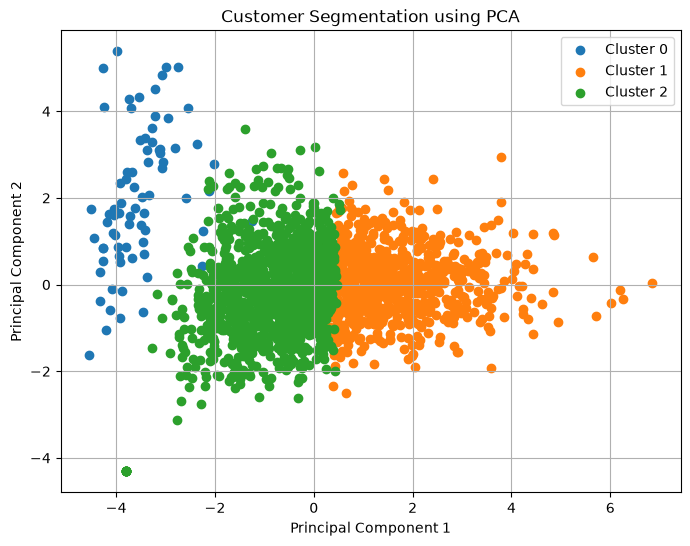

In [82]:
plt.figure(figsize=(8, 6))

for cluster in sorted(pca_df["customer_cluster"].unique()):
    
    cluster_data = pca_df[
        pca_df["customer_cluster"] == cluster
    ]
    
    plt.scatter(
        cluster_data["PC1"],
        cluster_data["PC2"],
        label=f"Cluster {cluster}"
    )

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("Customer Segmentation using PCA")
plt.legend()
plt.grid(True)

plt.savefig(
    "../outputs/figures/customer_pca.png",
    bbox_inches="tight"
)

plt.show()

In [83]:
print("Explained variance ratio:", pca.explained_variance_ratio_)
print("Total explained variance:", pca.explained_variance_ratio_.sum())

Explained variance ratio: [0.34451971 0.14489035]
Total explained variance: 0.4894100603366805


In [87]:
from sklearn.neighbors import NearestNeighbors

In [88]:
neighbors = NearestNeighbors(n_neighbors=10)

neighbors_fit = neighbors.fit(X_scaled)

distances, indices = neighbors_fit.kneighbors(X_scaled)

k_distances = distances[:, 9]

k_distances = np.sort(k_distances)

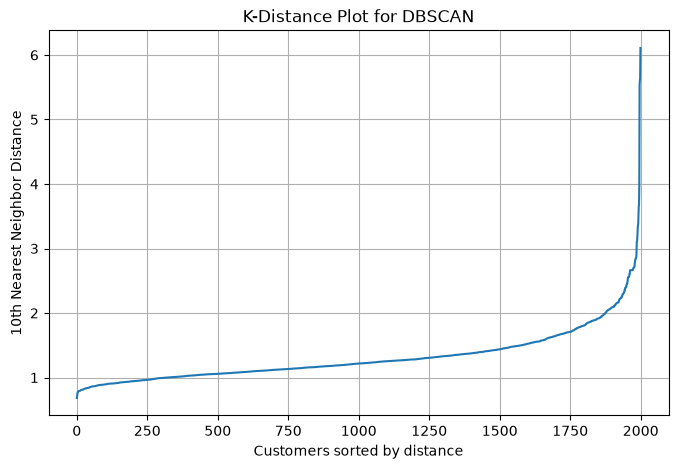

In [89]:
plt.figure(figsize=(8, 5))

plt.plot(k_distances)

plt.xlabel("Customers sorted by distance")
plt.ylabel("10th Nearest Neighbor Distance")
plt.title("K-Distance Plot for DBSCAN")

plt.grid(True)

plt.show()

In [90]:
eps_values = [0.8, 1.0, 1.2, 1.4, 1.6, 1.8, 2.0]

dbscan_results = []

for eps in eps_values:

    dbscan = DBSCAN(
        eps=eps,
        min_samples=10
    )

    labels = dbscan.fit_predict(X_scaled)

    n_clusters = len(
        set(labels) - {-1}
    )

    n_noise = (labels == -1).sum()

    if n_clusters > 1:
        mask = labels != -1

        silhouette = silhouette_score(
            X_scaled[mask],
            labels[mask]
        )
    else:
        silhouette = np.nan

    dbscan_results.append({
        "eps": eps,
        "clusters": n_clusters,
        "noise_points": n_noise,
        "noise_percentage": n_noise / len(labels) * 100,
        "silhouette_score": silhouette
    })

dbscan_results = pd.DataFrame(dbscan_results)

dbscan_results

,eps,clusters,noise_points,noise_percentage,silhouette_score
0,0.8,6,1914,95.70,0.337180
1,1.0,3,1212,60.60,0.080228
2,1.2,1,489,24.45,NaN
3,1.4,1,259,12.95,NaN
4,1.6,2,149,7.45,0.488724
5,1.8,2,81,4.05,0.471251
6,2.0,2,41,2.05,0.473755


In [92]:
final_dbscan = DBSCAN(
    eps=2.0,
    min_samples=10
)

customer_features["dbscan_cluster"] = (
    final_dbscan.fit_predict(X_scaled)
)
customer_features["dbscan_cluster"].value_counts().sort_index()

dbscan_cluster
-1      41
 0    1912
 1      47
Name: count, dtype: int64

In [93]:
dbscan_labels = customer_features["dbscan_cluster"].values

noise_mask = dbscan_labels == -1

n_clusters = len(
    set(dbscan_labels) - {-1}
)

n_noise = noise_mask.sum()

print("Number of clusters:", n_clusters)
print("Number of noise points:", n_noise)
print("Noise percentage:", round(n_noise / len(dbscan_labels) * 100, 2))

Number of clusters: 2
Number of noise points: 41
Noise percentage: 2.05


In [94]:
mask = dbscan_labels != -1

dbscan_silhouette = silhouette_score(
    X_scaled[mask],
    dbscan_labels[mask]
)

print("DBSCAN Silhouette Score:", round(dbscan_silhouette, 4))

DBSCAN Silhouette Score: 0.4738


In [95]:
dbscan_profile = customer_features[
    customer_features["dbscan_cluster"] != -1
].groupby("dbscan_cluster")[model_features].mean()

dbscan_profile

,total_orders,total_spending,average_order_value,average_items,weekend_orders,late_night_orders,ordering_frequency,average_rating_given
dbscan_cluster,,,,,,,,
0,5.154812,5406.510377,1047.269068,3.514141,1.493201,1.297594,0.103102,3.595768
1,1.085106,1154.548936,1052.285851,4.042553,0.297872,0.170213,1.000000,3.622811


In [96]:
noise_profile = customer_features[
    customer_features["dbscan_cluster"] == -1
][model_features].mean()

noise_profile

total_orders               2.268293
total_spending          2536.161951
average_order_value      814.207826
average_items              2.517477
weekend_orders             0.926829
late_night_orders          0.926829
ordering_frequency         0.729201
average_rating_given       3.030131
dtype: float64

### DBSCAN Interpretation

DBSCAN identified two dense behavioral groups and a small number of
customers as noise.

The noise customers represent behavior that does not closely match the
dominant customer patterns and may require further investigation.

DBSCAN therefore complements K-Means by identifying unusual behavioral
patterns rather than forcing every customer into a predefined cluster.

## Restaurant Segmentation

### Objective

The objective is to segment restaurants based on their operational performance,
customer demand, revenue, ratings, preparation time, cancellation rate, and
delivery performance.

This segmentation will help identify different restaurant profiles and
support targeted operational and business strategies.

###  Restaurant Feature Engineering

Restaurant-level features are created by aggregating order, delivery, and
review information at the restaurant level.

The selected features represent three major dimensions:

- **Demand:** Total orders and revenue
- **Customer experience:** Average rating
- **Operations:** Preparation time, cancellation rate, and delivery time

Restaurant identifiers are retained only for interpretation and are excluded
from model training.

In [124]:
restaurant_orders = orders.groupby("restaurant_id").agg(
    total_orders=("order_id", "count"),
    revenue=("order_amount", "sum"),
    cancellation_rate=(
        "order_status",
        lambda x: (x == "Cancelled").mean() * 100
    )
).reset_index()
restaurant_orders.head()

,restaurant_id,total_orders,revenue,cancellation_rate
0,R0001,93,102522.47,8.602151
1,R0002,101,102927.11,8.910891
2,R0003,99,109028.94,11.111111
3,R0004,96,97958.04,8.333333
4,R0005,98,109776.75,7.142857


In [125]:
deliveries = pd.read_csv("../data/raw/deliveries.csv")

print(deliveries.shape)
deliveries.head()

(10000, 9)


,delivery_id,order_id,driver_id,delivery_distance_km,preparation_time_minutes,traffic_condition,weather,delivery_time_minutes,tip_amount
0,DL00001,O00001,D0259,14.79,43,Medium,Rainy,128.9,164.01
1,DL00002,O00002,D0167,5.64,32,High,Clear,81.7,66.30
2,DL00003,O00003,D0471,9.75,41,High,Clear,98.1,149.36
3,DL00004,O00004,D0267,8.97,30,Medium,Rainy,90.8,211.23
4,DL00005,O00005,D0224,8.57,31,Medium,Cloudy,81.1,36.35


In [126]:
restaurants = pd.read_csv("../data/raw/restaurants.csv")

print(restaurants.shape)
restaurants.head()

(100, 6)


,restaurant_id,restaurant_name,restaurant_category,city,restaurant_rating,avg_preparation_time
0,R0001,Odom PLC,Indian,Bangalore,4.0,15
1,R0002,Gutierrez LLC,Desserts,Chennai,3.9,22
2,R0003,Hawkins PLC,Fast Food,Bangalore,4.2,31
3,R0004,"Buck, Garrett and Simmons",Italian,Mumbai,4.2,40
4,R0005,Williams-Cooper,Desserts,Delhi,3.3,31


In [127]:
restaurant_delivery = deliveries.merge(
    orders[["order_id", "restaurant_id"]],
    on="order_id",
    how="left"
)

restaurant_delivery = restaurant_delivery.groupby("restaurant_id").agg(
    average_preparation_time=("preparation_time_minutes", "mean"),
    average_delivery_time=("delivery_time_minutes", "mean")
).reset_index()

restaurant_delivery.head()

,restaurant_id,average_preparation_time,average_delivery_time
0,R0001,27.494624,75.329032
1,R0002,27.336634,75.662376
2,R0003,26.777778,72.281818
3,R0004,24.770833,70.775000
4,R0005,25.836735,73.885714


In [128]:
restaurant_reviews = reviews.merge(
    orders[["order_id", "restaurant_id"]],
    on="order_id",
    how="left"
)

restaurant_reviews = restaurant_reviews.groupby(
    "restaurant_id"
).agg(
    average_rating=("rating", "mean")
).reset_index()

restaurant_reviews.head()

,restaurant_id,average_rating
0,R0001,3.338462
1,R0002,3.708333
2,R0003,3.455882
3,R0004,3.516667
4,R0005,3.700000


###  Combining Restaurant Features

The aggregated datasets are merged using `restaurant_id` to create a single
restaurant-level analytical dataset.

Each row represents one restaurant and contains the behavioral and
operational metrics required for segmentation.

In [129]:
restaurant_features = restaurants[
    ["restaurant_id", "restaurant_name", "restaurant_category", "city"]
].copy()

restaurant_features = restaurant_features.merge(
    restaurant_orders,
    on="restaurant_id",
    how="left"
)

restaurant_features = restaurant_features.merge(
    restaurant_delivery,
    on="restaurant_id",
    how="left"
)

restaurant_features = restaurant_features.merge(
    restaurant_reviews,
    on="restaurant_id",
    how="left"
)
print("Shape:", restaurant_features.shape)

restaurant_features.head()

Shape: (100, 10)


,restaurant_id,restaurant_name,restaurant_category,city,total_orders,revenue,cancellation_rate,average_preparation_time,average_delivery_time,average_rating
0,R0001,Odom PLC,Indian,Bangalore,93,102522.47,8.602151,27.494624,75.329032,3.338462
1,R0002,Gutierrez LLC,Desserts,Chennai,101,102927.11,8.910891,27.336634,75.662376,3.708333
2,R0003,Hawkins PLC,Fast Food,Bangalore,99,109028.94,11.111111,26.777778,72.281818,3.455882
3,R0004,"Buck, Garrett and Simmons",Italian,Mumbai,96,97958.04,8.333333,24.770833,70.775000,3.516667
4,R0005,Williams-Cooper,Desserts,Delhi,98,109776.75,7.142857,25.836735,73.885714,3.700000


In [130]:
print("Shape:", restaurant_features.shape)

restaurant_features.isnull().sum()

Shape: (100, 10)


restaurant_id               0
restaurant_name             0
restaurant_category         0
city                        0
total_orders                0
revenue                     0
cancellation_rate           0
average_preparation_time    0
average_delivery_time       0
average_rating              0
dtype: int64

### Missing Value Treatment

Some restaurants may not have sufficient review or delivery records, which
can result in missing aggregated values.

For numerical restaurant performance features, missing values are replaced
using the median of the corresponding feature. Median imputation is used
because it is less sensitive to extreme values than the mean.

In [131]:
restaurant_model_features = [
    "total_orders",
    "revenue",
    "average_rating",
    "average_preparation_time",
    "cancellation_rate",
    "average_delivery_time"
]

for col in restaurant_model_features:
    restaurant_features[col] = restaurant_features[col].fillna(
        restaurant_features[col].median()
    )

restaurant_features[restaurant_model_features].isnull().sum()

total_orders                0
revenue                     0
average_rating              0
average_preparation_time    0
cancellation_rate           0
average_delivery_time       0
dtype: int64

### Exploratory Summary

Before clustering, the restaurant-level features are examined using
descriptive statistics to understand their distributions and identify
potential differences in scale.

In [132]:
restaurant_features[restaurant_model_features].describe()

,total_orders,revenue,average_rating,average_preparation_time,cancellation_rate,average_delivery_time
count,100.000000,100.00000,100.000000,100.000000,100.000000,100.000000
mean,100.000000,104954.94280,3.589434,26.858489,8.172474,74.799582
std,9.304067,10484.88704,0.160363,0.940421,2.722626,1.999208
min,77.000000,82659.37000,3.115942,24.770833,2.777778,70.112397
25%,93.750000,97359.86500,3.485064,26.231632,6.076985,73.466586
50%,101.000000,103855.35500,3.590537,26.865581,8.084107,74.893186
75%,105.250000,110925.41250,3.687479,27.497372,9.739909,76.060935
max,122.000000,135045.87000,4.095238,28.973913,15.476190,79.762222


### Feature Scaling

The restaurant features have different units and ranges. For example,
revenue is measured in currency, while ratings are measured on a rating
scale and preparation time is measured in minutes.

StandardScaler is therefore used to standardize the features before applying
K-Means and DBSCAN.

Standardization prevents features with larger numerical scales from
dominating the distance calculations used by clustering algorithms.

In [133]:
from sklearn.preprocessing import StandardScaler

scaler_restaurant = StandardScaler()

X_restaurant = scaler_restaurant.fit_transform(
    restaurant_features[restaurant_model_features]
)

X_restaurant.shape

(100, 6)

In [139]:
restaurant_results = []

for k in range(2, 9):

    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    labels = kmeans.fit_predict(X_restaurant)

    restaurant_results.append({
        "k": k,
        "inertia": kmeans.inertia_,
        "silhouette_score": silhouette_score(
            X_restaurant,
            labels
        )
    })

restaurant_results = pd.DataFrame(restaurant_results)

restaurant_results

,k,inertia,silhouette_score
0,2,475.079250,0.177293
1,3,402.709106,0.177957
2,4,360.525288,0.171402
3,5,327.532936,0.165897
4,6,296.570915,0.170459
5,7,271.455982,0.166875
6,8,248.733899,0.177908


### Selecting the Number of Restaurant Clusters

K-Means was evaluated for values of K ranging from 2 to 8 using both
inertia and Silhouette Score.

The highest Silhouette Score was obtained with K=3, with a score of
approximately 0.178.

Although the overall Silhouette Score is relatively low, K=3 provides a
simple and interpretable segmentation while maintaining the best
Silhouette Score among the tested values.

Therefore, K=3 is selected for the final restaurant segmentation model.

### Final Restaurant K-Means Model

A final K-Means model with three clusters is trained using the standardized
restaurant-level features.


In [140]:
restaurant_kmeans = KMeans(
    n_clusters=3,
    random_state=42,
    n_init=10
)

restaurant_features["restaurant_cluster"] = (
    restaurant_kmeans.fit_predict(X_restaurant)
)

restaurant_features["restaurant_cluster"].value_counts().sort_index()

restaurant_cluster
0    34
1    26
2    40
Name: count, dtype: int64

In [141]:
restaurant_profile = restaurant_features.groupby(
    "restaurant_cluster"
)[restaurant_model_features].mean()

restaurant_profile

restaurant_profile.sort_values(
    "revenue",
    ascending=False
)

,total_orders,revenue,average_rating,average_preparation_time,cancellation_rate,average_delivery_time
restaurant_cluster,,,,,,
2,107.775000,114136.207250,3.573735,26.667991,7.083829,74.375865
0,96.000000,100576.669706,3.630060,26.512848,10.716532,74.083095
1,93.269231,96555.354615,3.560459,27.603553,6.520468,76.388398


### Restaurant Cluster Profiles

The three restaurant clusters were analyzed using their average operational
and business metrics.

**Cluster 2 – High-Demand / High-Revenue Restaurants**

These restaurants generate the highest order volume and revenue. Their
preparation and delivery performance is relatively stable, making this
cluster the strongest contributor to overall business performance.

**Cluster 0 – High-Rated but High-Cancellation Restaurants**

These restaurants have the highest average customer rating and relatively
fast preparation and delivery times. However, they also have the highest
cancellation rate, indicating a potential operational issue that should be
investigated.

**Cluster 1 – Lower-Demand / Delivery-Delay Restaurants**

These restaurants have the lowest order volume and revenue. They also have
the longest preparation and delivery times. Although their cancellation
rate is relatively low, improving operational speed and demand generation
could improve their performance.

### PCA Visualization

Principal Component Analysis (PCA) is used to reduce the standardized
restaurant features to two dimensions for visualization.

PCA does not perform the clustering itself. Instead, it helps visualize
whether the restaurant clusters identified by K-Means occupy different
regions of the feature space.

In [142]:
from sklearn.decomposition import PCA

pca_restaurant = PCA(n_components=2)

restaurant_pca = pca_restaurant.fit_transform(X_restaurant)

restaurant_pca_df = pd.DataFrame(
    restaurant_pca,
    columns=["PC1", "PC2"]
)

restaurant_pca_df["restaurant_cluster"] = (
    restaurant_features["restaurant_cluster"].values
)

restaurant_pca_df.head()

,PC1,PC2,restaurant_cluster
0,-1.049390,0.329238,1
1,-0.310507,0.353130,0
2,0.540256,-1.025094,0
3,0.660601,-2.756915,0
4,0.712562,-0.754124,2


In [143]:
print(
    "Explained variance ratio:",
    pca_restaurant.explained_variance_ratio_
)

print(
    "Total explained variance:",
    pca_restaurant.explained_variance_ratio_.sum()
)

Explained variance ratio: [0.32751249 0.25026952]
Total explained variance: 0.5777820157389766


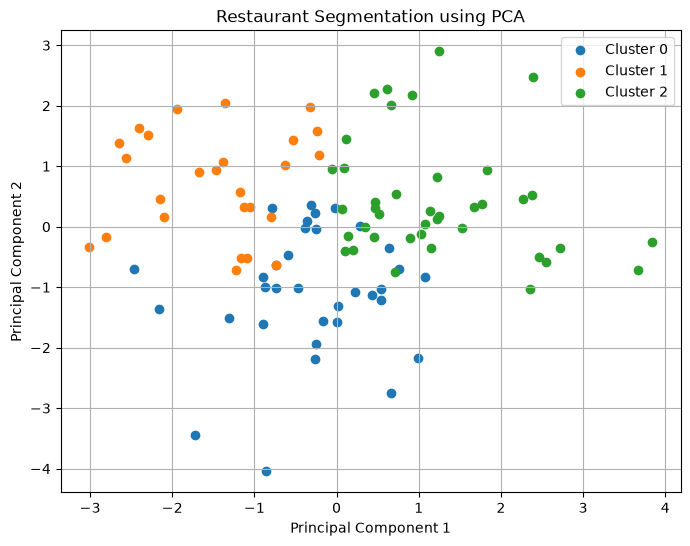

In [144]:
plt.figure(figsize=(8, 6))

for cluster in sorted(
    restaurant_pca_df["restaurant_cluster"].unique()
):
    
    cluster_data = restaurant_pca_df[
        restaurant_pca_df["restaurant_cluster"] == cluster
    ]
    
    plt.scatter(
        cluster_data["PC1"],
        cluster_data["PC2"],
        label=f"Cluster {cluster}"
    )

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("Restaurant Segmentation using PCA")
plt.legend()
plt.grid(True)

plt.show()

### PCA Interpretation

The first principal component explains approximately 32.75% of the
variation in the standardized restaurant features, while the second
principal component explains approximately 25.03%.

Together, PC1 and PC2 explain approximately 57.78% of the total variance.

The PCA visualization provides a two-dimensional view of the restaurant
clusters. It is used only for visualization and does not replace the
original standardized features used by K-Means.

### PCA Visualization Interpretation

The PCA plot shows some separation between the three restaurant clusters,
but there is also noticeable overlap between groups.

This is consistent with the relatively low Silhouette Score observed during
K-Means evaluation and suggests that restaurant characteristics form
gradual rather than strongly separated behavioral groups.

### DBSCAN Clustering

DBSCAN (Density-Based Spatial Clustering of Applications with Noise) is
applied as a complementary clustering method.

Unlike K-Means, DBSCAN does not require the number of clusters to be
specified in advance. It identifies dense regions of observations and
classifies observations that do not belong to sufficiently dense regions
as noise.

The main parameters evaluated are `eps` and `min_samples`.

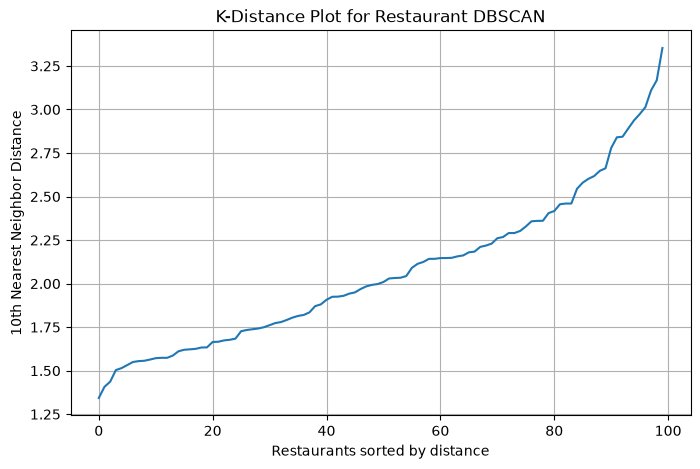

In [146]:
from sklearn.neighbors import NearestNeighbors
import numpy as np
import matplotlib.pyplot as plt

neighbors = NearestNeighbors(n_neighbors=10)

neighbors_fit = neighbors.fit(X_restaurant)

distances, indices = neighbors_fit.kneighbors(X_restaurant)

k_distances = np.sort(distances[:, -1])

plt.figure(figsize=(8, 5))

plt.plot(k_distances)

plt.xlabel("Restaurants sorted by distance")
plt.ylabel("10th Nearest Neighbor Distance")
plt.title("K-Distance Plot for Restaurant DBSCAN")

plt.grid(True)
plt.show()

### DBSCAN Parameter Tuning

The K-distance plot is used to identify a reasonable range of `eps`
values for DBSCAN.

The curve begins to increase more sharply around the 2.4–2.6 range.
Therefore, multiple nearby `eps` values are evaluated rather than
selecting a single value directly from the plot.

The `min_samples` parameter is kept fixed at 10 for this analysis.

In [152]:
eps_values = [1.4, 1.5, 1.6, 1.7, 1.8, 1.9, 2.0]

dbscan_final_results = []

for eps in eps_values:

    dbscan = DBSCAN(
        eps=eps,
        min_samples=2
    )

    labels = dbscan.fit_predict(X_restaurant)

    n_clusters = len(set(labels)) - (
        1 if -1 in labels else 0
    )

    noise_points = (labels == -1).sum()

    noise_percentage = (
        noise_points / len(labels) * 100
    )

    non_noise_mask = labels != -1

    if n_clusters >= 2:
        silhouette = silhouette_score(
            X_restaurant[non_noise_mask],
            labels[non_noise_mask]
        )
    else:
        silhouette = np.nan

    dbscan_final_results.append({
        "eps": eps,
        "min_samples": 2,
        "clusters": n_clusters,
        "noise_points": noise_points,
        "noise_percentage": noise_percentage,
        "silhouette_score": silhouette
    })

dbscan_final_results = pd.DataFrame(
    dbscan_final_results
)

dbscan_final_results

,eps,min_samples,clusters,noise_points,noise_percentage,silhouette_score
0,1.4,2,9,23,23.0,-0.005255
1,1.5,2,7,18,18.0,-0.053983
2,1.6,2,5,15,15.0,-0.013240
3,1.7,2,4,10,10.0,0.031657
4,1.8,2,3,9,9.0,0.159085
5,1.9,2,3,8,8.0,0.156319
6,2.0,2,2,6,6.0,0.318503


### Final DBSCAN Configuration

Based on the parameter evaluation, the final DBSCAN configuration is:

- `eps = 2.0`
- `min_samples = 2`

This configuration produces two clusters with 6% of restaurants classified
as noise and achieves a Silhouette Score of approximately 0.319.

Lower `eps` values produced fragmented clusters, higher noise levels, or
negative/very low Silhouette Scores.

Although `min_samples=2` is relatively permissive, this configuration
provided the most useful density-based structure among the tested
parameters and was therefore selected for comparison with K-Means.

In [153]:
final_dbscan = DBSCAN(
    eps=2.0,
    min_samples=2
)

restaurant_features["dbscan_cluster"] = (
    final_dbscan.fit_predict(X_restaurant)
)

restaurant_features["dbscan_cluster"].value_counts().sort_index()

dbscan_cluster
-1     6
 0    92
 1     2
Name: count, dtype: int64

In [156]:
dbscan_restaurant_profile = restaurant_features.groupby(
    "dbscan_cluster"
)[restaurant_model_features].mean()

dbscan_restaurant_profile

dbscan_restaurant_profile.sort_values(
    "revenue",
    ascending=False
)

,total_orders,revenue,average_rating,average_preparation_time,cancellation_rate,average_delivery_time
dbscan_cluster,,,,,,
-1,106.000000,113794.430000,3.608031,26.817315,8.539394,74.170778
0,99.956522,104769.826196,3.588976,26.897306,8.002708,74.895330
1,84.000000,86951.845000,3.554708,25.196429,14.880952,72.281548


### DBSCAN Cluster Profiling

The final DBSCAN labels are analyzed using the same restaurant-level
business metrics used for K-Means.

This allows the density-based segmentation to be interpreted from a
business perspective and compared consistently with the K-Means results.
Restaurants assigned to cluster `-1` are treated as noise points and
represent restaurants that do not belong to a sufficiently dense group.

###  DBSCAN Cluster Interpretation

DBSCAN identified two main density-based clusters and six noise points.

**Cluster 0 – Mainstream Restaurants**

Cluster 0 contains the majority of restaurants (92 out of 100). These
restaurants show relatively average values across order volume, revenue,
ratings, preparation time, cancellation rate, and delivery time. They
represent the dominant operating pattern in the dataset.

**Cluster 1 – High-Cancellation Restaurants**

Cluster 1 contains only two restaurants. These restaurants have lower
order volume and revenue compared with the other groups and the highest
cancellation rate. Although their preparation and delivery times are
relatively fast, their high cancellation rate indicates a potential
operational or customer-experience issue.

**Noise Points – Exceptional Restaurants**

DBSCAN classified six restaurants as noise because they did not belong to
either dense group. These restaurants have the highest average order
volume and revenue and relatively strong ratings. They may represent
high-performing restaurants with characteristics that differ from the
dominant restaurant population.

### K-Means vs DBSCAN Comparison

K-Means and DBSCAN produced different views of restaurant behavior.

K-Means generated three relatively balanced clusters and provided more
detailed business segmentation. The resulting clusters could be interpreted
based on demand, revenue, customer ratings, cancellation rates, and delivery
performance.

DBSCAN achieved a higher Silhouette Score of approximately 0.319 compared
with approximately 0.178 for K-Means. However, DBSCAN assigned 92% of
restaurants to a single cluster, only two restaurants to the second
cluster, and six restaurants as noise.

Therefore, while DBSCAN provides stronger density-based separation,
K-Means is considered more useful for the final restaurant segmentation
because it provides more balanced and actionable business segments.
DBSCAN is retained as a complementary analysis for identifying unusual
restaurants and potential outliers.